SmartFin - Credit Score Prediction System

✓ Libraries imported successfully

Loading datasets...
✓ Training data loaded: (150000, 11)
✓ Test data loaded: (101503, 11)

Features: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Training Data - Exploratory Data Analysis

Dataset Shape: (150000, 11)

Column Data Types:
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
Num

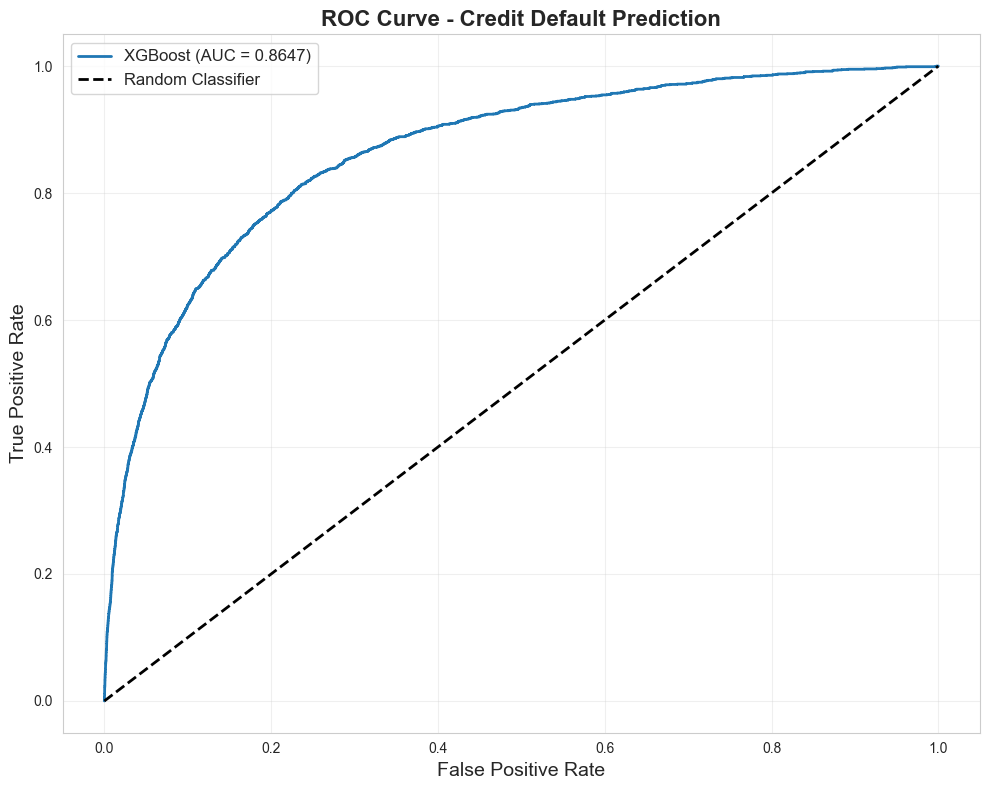


Generating credit score distribution plot...
✓ Distribution plot saved to score_distribution.png


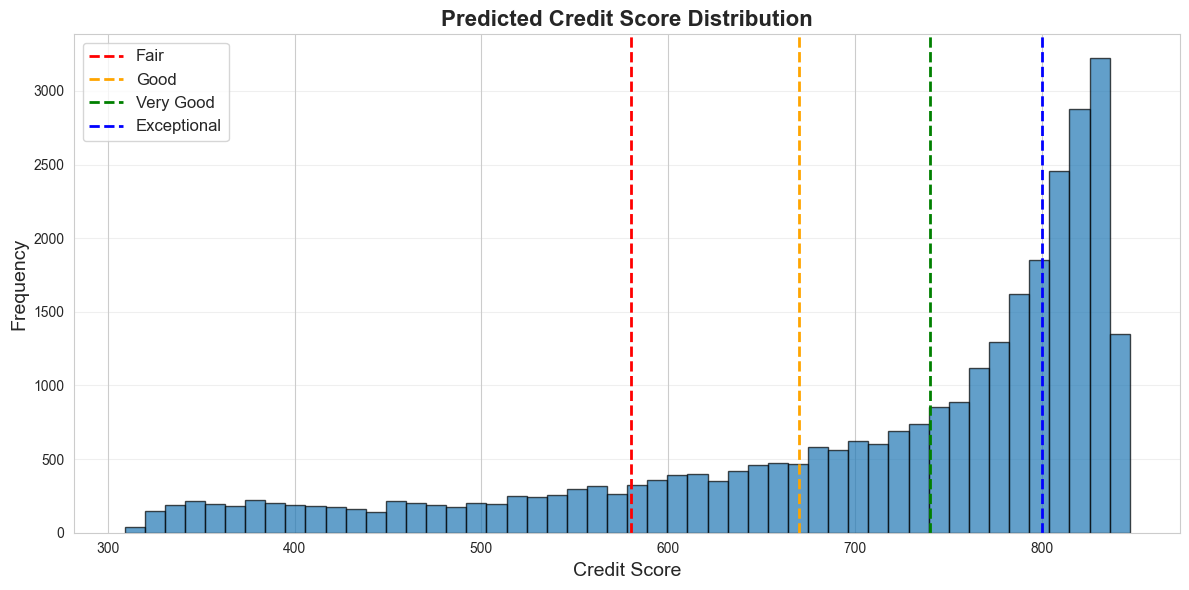


SHAP EXPLAINABILITY INITIALIZATION

Creating SHAP explainer...
✓ SHAP explainer initialized

Generating global feature importance plot...
✓ Plot saved to shap_global_importance.png


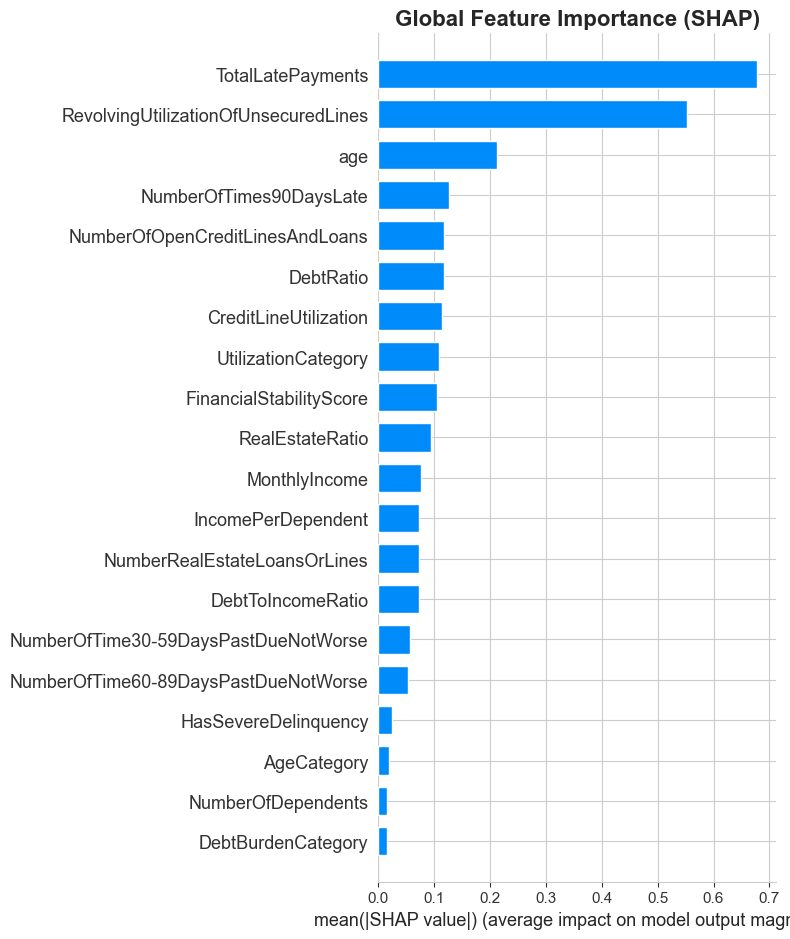


CREDIT SCORE EXPLANATION

Credit Score: 834 (Exceptional)
Default Probability: 2.82%

Top Contributing Factors:
--------------------------------------------------------------------------------
1. RevolvingUtilizationOfUnsecuredLines
   - SHAP Value: -0.8541
   - Impact: This feature decreases default risk, affecting credit score positively
   - Insight: Credit utilization affects available credit capacity

2. TotalLatePayments
   - SHAP Value: -0.7438
   - Impact: This feature decreases default risk, affecting credit score positively
   - Insight: Payment history is a critical factor in credit scoring

3. age
   - SHAP Value: -0.4466
   - Impact: This feature decreases default risk, affecting credit score positively

4. CreditLineUtilization
   - SHAP Value: -0.2910
   - Impact: This feature decreases default risk, affecting credit score positively
   - Insight: Credit utilization affects available credit capacity

5. MonthlyIncome
   - SHAP Value: -0.1732
   - Impact: This feature de

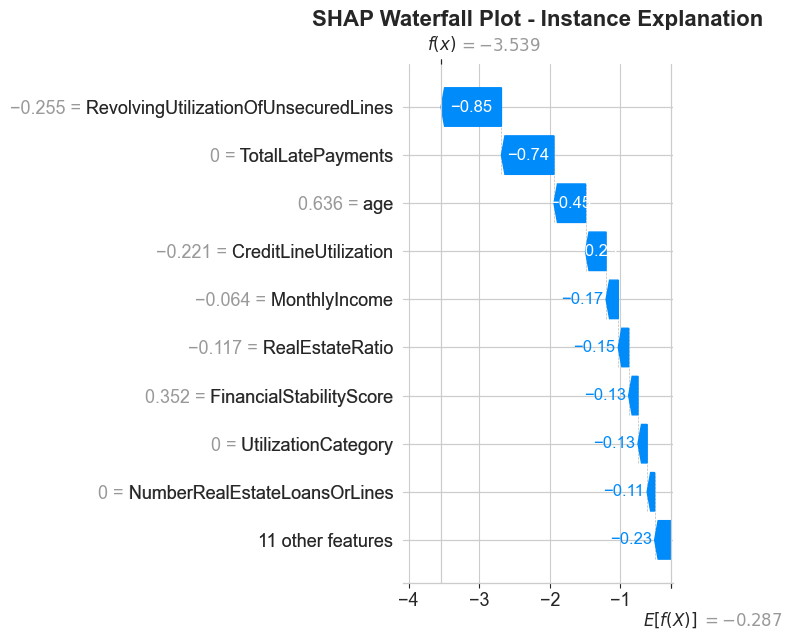


WHAT-IF ANALYSIS


Handling missing values...
✓ Missing values handled

Handling outliers...
✓ Outliers handled

Engineering features...
✓ Created 10 engineered features


Handling missing values...
✓ Missing values handled

Handling outliers...
✓ Outliers handled

Engineering features...
✓ Created 10 engineered features


WHAT-IF ANALYSIS REPORT

CURRENT SITUATION:
--------------------------------------------------------------------------------
Credit Score: 392
Default Probability: 83.28%
Rating: Poor

SIMULATED CHANGES:
--------------------------------------------------------------------------------
  • DebtRatio: Changed to 0.5620874902999999

PROJECTED OUTCOME:
--------------------------------------------------------------------------------
New Credit Score: 413
New Default Probability: 79.54%
New Rating: Poor

IMPACT ANALYSIS:
--------------------------------------------------------------------------------
Credit Score Change: +21 points
Probability Change: -3.73%

✓ Improvement

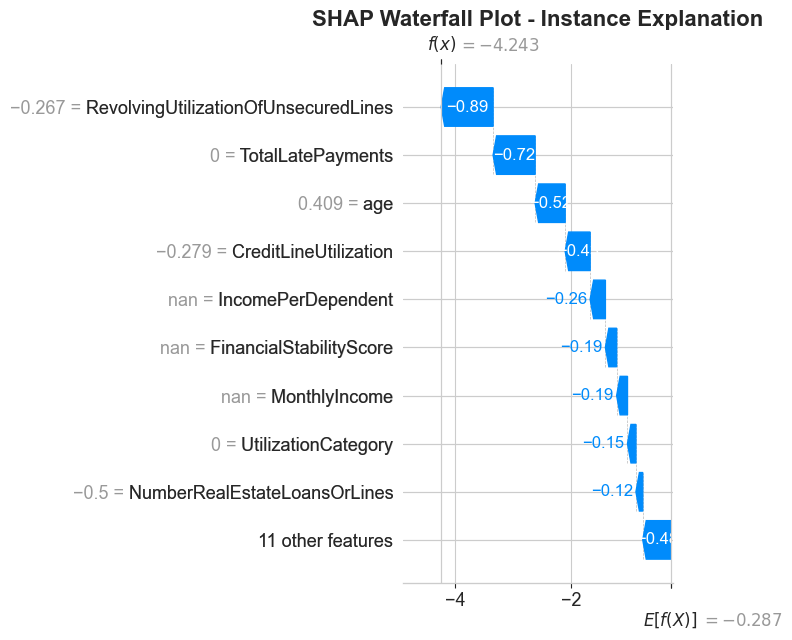


WHAT-IF ANALYSIS

Current Debt Ratio: 15.0000

Handling missing values...
  - MonthlyIncome: Filled 1 values with median (nan)
✓ Missing values handled

Handling outliers...
✓ Outliers handled

Engineering features...
✓ Created 10 engineered features


Handling missing values...
  - MonthlyIncome: Filled 1 values with median (nan)
✓ Missing values handled

Handling outliers...
✓ Outliers handled

Engineering features...
✓ Created 10 engineered features


WHAT-IF ANALYSIS REPORT

CURRENT SITUATION:
--------------------------------------------------------------------------------
Credit Score: 842
Default Probability: 1.42%
Rating: Exceptional

SIMULATED CHANGES:
--------------------------------------------------------------------------------
  • DebtRatio: Changed to 7.5

PROJECTED OUTCOME:
--------------------------------------------------------------------------------
New Credit Score: 842
New Default Probability: 1.42%
New Rating: Exceptional

IMPACT ANALYSIS:
-----------------------

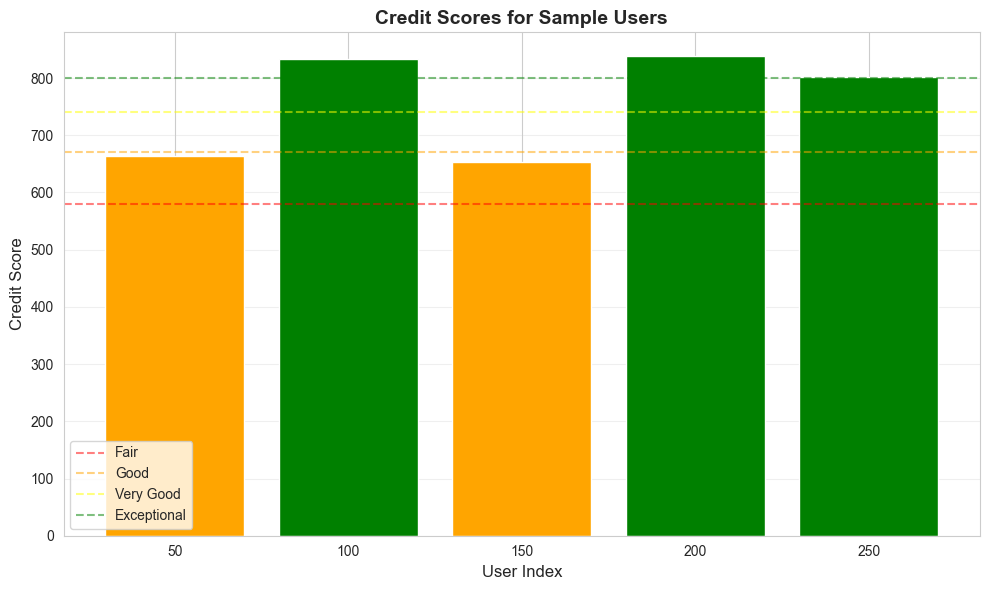

In [1]:
# Cell 1: Import the module
import sys
sys.path.append('../src')

from credit_score_model import *
import warnings
warnings.filterwarnings('ignore')

# Cell 2: Run the pipeline
results = main(
    train_path='../data/cs-training.csv',
    test_path='../data/cs-test.csv'
)

# Cell 3: Extract components
model = results['model']
preprocessor = results['preprocessor']
shap_explainer = results['shap_explainer']
what_if_analyzer = results['what_if_analyzer']
output_df = results['output_df']

print("✓ Model pipeline completed successfully!")

# Cell 4: Example - Single user prediction (FIXED)
# Load original data and properly clean it
train_df = pd.read_csv('../data/cs-training.csv')

# Drop 'Unnamed: 0' column if it exists
if 'Unnamed: 0' in train_df.columns:
    train_df = train_df.drop('Unnamed: 0', axis=1)

# Extract a test instance (without the target variable)
test_instance = train_df.drop('SeriousDlqin2yrs', axis=1).iloc[[100]].copy()

print(f"Test instance shape: {test_instance.shape}")
print(f"Columns: {list(test_instance.columns)}")

# Preprocess using the fitted preprocessor
test_processed, _ = preprocessor.transform(test_instance)

# Predict
prob = model.predict_proba(test_processed)[0]
score = CreditScoreConverter.probability_to_score(prob)
category = CreditScoreConverter.score_to_category(score)

print(f"\n{'='*60}")
print(f"PREDICTION RESULTS")
print(f"{'='*60}")
print(f"Credit Score: {score}")
print(f"Credit Category: {category}")
print(f"Default Probability: {prob:.2%}")
print(f"{'='*60}\n")

# Cell 5: SHAP explanation
shap_values = shap_explainer.explain_instance(test_processed)
explanation = shap_explainer.generate_text_explanation(
    test_processed.iloc[0],
    shap_values,
    score,
    prob
)
print(explanation)

# Plot instance explanation
shap_explainer.plot_instance_explanation(test_processed)

# Cell 6: What-if analysis
print("\n" + "="*60)
print("WHAT-IF ANALYSIS")
print("="*60 + "\n")

# Scenario 1: What if debt ratio is reduced?
current_debt = test_instance['DebtRatio'].values[0]
print(f"Current Debt Ratio: {current_debt:.4f}")

what_if_results_1 = what_if_analyzer.simulate_changes(
    test_instance,
    {'DebtRatio': current_debt * 0.5}
)
report_1 = what_if_analyzer.generate_what_if_report(what_if_results_1)
print(report_1)

# Scenario 2: What if income increases and late payments eliminated?
current_income = test_instance['MonthlyIncome'].values[0]
what_if_results_2 = what_if_analyzer.simulate_changes(
    test_instance,
    {
        'MonthlyIncome': current_income * 1.3,
        'NumberOfTime30-59DaysPastDueNotWorse': 0,
        'NumberOfTimes90DaysLate': 0
    }
)
report_2 = what_if_analyzer.generate_what_if_report(what_if_results_2)
print(report_2)

# Cell 7: Get improvement suggestions
print("\n" + "="*60)
print("IMPROVEMENT SUGGESTIONS")
print("="*60 + "\n")

suggestions = what_if_analyzer.suggest_improvements(test_instance, target_score_increase=50)

for i, suggestion in enumerate(suggestions, 1):
    print(f"\n{'─'*60}")
    print(f"Suggestion {i}: {suggestion['description']}")
    print(f"{'─'*60}")
    print(f"Rationale: {suggestion['rationale']}")
    print(f"Projected Impact: {suggestion['projected_impact']:+d} points")
    print(f"Current Score: {score} → New Score: {suggestion['new_score']}")
    print(f"Changes Required:")
    for feature, value in suggestion['changes'].items():
        original_value = test_instance[feature].values[0]
        print(f"  • {feature}: {original_value:.2f} → {value:.2f}")

# Cell 8: Batch predictions for multiple users
print("\n" + "="*60)
print("BATCH PREDICTIONS")
print("="*60 + "\n")

# Select 5 random users
sample_indices = [50, 100, 150, 200, 250]
batch_instances = train_df.drop('SeriousDlqin2yrs', axis=1).iloc[sample_indices].copy()

# Preprocess
batch_processed, _ = preprocessor.transform(batch_instances)

# Predict
batch_probs = model.predict_proba(batch_processed)
batch_scores = CreditScoreConverter.probability_to_score(batch_probs)
batch_categories = [CreditScoreConverter.score_to_category(s) for s in batch_scores]

# Create results DataFrame
batch_results = pd.DataFrame({
    'User_Index': sample_indices,
    'Credit_Score': batch_scores,
    'Category': batch_categories,
    'Default_Prob': [f"{p:.2%}" for p in batch_probs],
    'Age': batch_instances['age'].values,
    'Income': batch_instances['MonthlyIncome'].values,
    'DebtRatio': batch_instances['DebtRatio'].values
})

print(batch_results.to_string(index=False))

# Cell 9: Visualize score distribution for batch
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(range(len(batch_scores)), batch_scores, color=['red' if s < 580 else 'orange' if s < 670 else 'yellow' if s < 740 else 'lightgreen' if s < 800 else 'green' for s in batch_scores])
plt.xlabel('User Index', fontsize=12)
plt.ylabel('Credit Score', fontsize=12)
plt.title('Credit Scores for Sample Users', fontsize=14, fontweight='bold')
plt.xticks(range(len(batch_scores)), sample_indices)
plt.axhline(y=580, color='red', linestyle='--', alpha=0.5, label='Fair')
plt.axhline(y=670, color='orange', linestyle='--', alpha=0.5, label='Good')
plt.axhline(y=740, color='yellow', linestyle='--', alpha=0.5, label='Very Good')
plt.axhline(y=800, color='green', linestyle='--', alpha=0.5, label='Exceptional')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
